# Python Lesson 48: Expectation, Variance and Covariance (Dice)

**Concept page:** `wiki/concepts/expectation-variance-covariance.md` · **Area:** probability

**You will be able to:**
- compute mean/variance of fair and loaded dice
- derive the pmf of the sum of two dice
- check Var(X+Y)=VarX+VarY+2Cov

*How to use:* run the cells top to bottom, read the output, then try the **Exercises** in the empty cells before opening the **Solutions** section at the bottom.

In [1]:
import numpy as np
import sympy as sp
import matplotlib
import matplotlib.pyplot as plt
np.set_printoptions(precision=4, suppress=True)
%matplotlib inline

## 1. Fair die

In [2]:
faces=np.arange(1,7); p=np.full(6,1/6)
mean=(faces*p).sum(); var=((faces-mean)**2*p).sum(); print(mean,var,35/12)

3.5 2.9166666666666665 2.9166666666666665


## 2. Sum of two throws – exact pmf

{np.int64(2): np.float64(0.0278), np.int64(3): np.float64(0.0556), np.int64(4): np.float64(0.0833), np.int64(5): np.float64(0.1111), np.int64(6): np.float64(0.1389), np.int64(7): np.float64(0.1667), np.int64(8): np.float64(0.1389), np.int64(9): np.float64(0.1111), np.int64(10): np.float64(0.0833), np.int64(11): np.float64(0.0556), np.int64(12): np.float64(0.0278)}


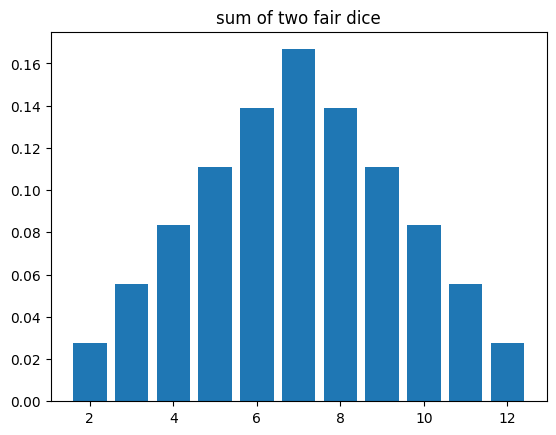

In [3]:
pm=np.convolve(p,p); sums=np.arange(2,13); print(dict(zip(sums,np.round(pm,4))))
plt.bar(sums,pm); plt.title("sum of two fair dice"); plt.show()

## 3. Simulation and covariance

In [4]:
rng=np.random.default_rng(0); a=rng.integers(1,7,200000); b=rng.integers(1,7,200000)
print(np.cov(a,b)[0,1], (a+b).mean(), (a+b).var(), 2*35/12)

-0.006600151900759545 6.9993 5.81249951 5.833333333333333


## 4. Loaded die: side 6 twice as likely

In [5]:
pl=np.array([1,1,1,1,1,2])/7; ml=(faces*pl).sum(); vl=((faces-ml)**2*pl).sum(); print(ml,vl)
print(np.bincount(rng.choice(faces,size=100000,p=pl))[1:]/100000)

3.8571428571428568 3.2653061224489797
[0.143  0.1427 0.1427 0.1434 0.1426 0.2857]


## 5. Dependent rolls: covariance is not 0

In [6]:
x=rng.integers(1,7,100000); y=np.where(rng.random(100000)<0.5,x,rng.integers(1,7,100000))   # second roll copies the first half the time
c=np.cov(x,y)[0,1]; print(c, np.var(x+y,ddof=1), x.var(ddof=1)+y.var(ddof=1)+2*c)

1.4413151431514257 8.732743487434874 8.732743487434863


## Cambodian textbook corner (កម្មវិធីសិក្សាកម្ពុជា)
Textbook link: Grade 12 advanced ch. 6 builds the distribution table of the number of 3s in three dice rolls and requires Σp=1 — check the same property here.

In [7]:
print(pm.sum())

1.0


## Exercises

**Exercise 1.** Mean and variance of a fair 4-sided die and of the sum of two throws (2.5, 1.25, 5, 2.5).

In [8]:
# your code here

**Exercise 2.** Exact pmf of the sum of two fair 4-sided dice.

In [9]:
# your code here

## Solutions
*(Try the exercises first!)*

In [10]:
# Solution 1
f=np.arange(1,5); q=np.full(4,.25); m=(f*q).sum(); v=((f-m)**2*q).sum(); print(m,v,2*m,2*v); assert (m,v)==(2.5,1.25)

2.5 1.25 5.0 2.5


In [11]:
# Solution 2
pm4=np.convolve(np.full(4,.25),np.full(4,.25)); print(pm4); assert np.isclose(pm4.sum(),1) and np.isclose(pm4[3],0.25) and np.isclose(pm4[0],1/16)

[0.0625 0.125  0.1875 0.25   0.1875 0.125  0.0625]
